<a href="https://colab.research.google.com/github/Suharyanto-env/Sampah-Dumai/blob/main/IPS2_Indeks_%26_WLRSI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PERHITUNGAN INDEKS PENGELOLAAN SAMPAH (IPS) KAB/KOTA**
======================================================================

* **Definisi**:
  Indeks kuantitatif berbasis neraca massa untuk menilai kinerja pengelolaan sampah di tingkat kabupaten/kota dan kecamatan.

* **Tujuan**:
  * Menyediakan baseline kondisi pengelolaan sampah daerah
  * Mendukung penyusunan RISPS dan program KIE/penyuluhan
  * Mengukur capaian kinerja secara terstandar
  * Menentukan prioritas intervensi pengurangan kebocoran sampah

* **Ruang Lingkup**:
  * Timbulan sampah (S) = Terkelola (K) + Unmanaged (L)
  * **Terkelola (K)**: TPA SL, sarpras (BS/TPS3R/TPST), pengelolaan mandiri RT, reduksi sektor informal
  * **Unmanaged (L)**: TPA open dumping, leaked (TPS liar), hidden (tidak terdata)

* **Metodologi**:
  IPS dihitung dari proporsi sampah terkelola terhadap total timbulan:
  IPS = ((K/S) − 0,65) / 0,35
  dengan batas nilai: −1 ≤ IPS ≤ 1

* **Interpretasi**:
  * IPS = 1 → 100% sampah terkelola
  * IPS = 0 → 65% terkelola (ambang kebijakan nasional)
  * IPS = −1 → 100% sampah tidak terkelola

* **Pemanfaatan**:
  * Evaluasi kinerja antar wilayah
  * Monitoring capaian target nasional
  * Dasar kebijakan berbasis data (evidence-based)
  * Komunikasi kinerja kepada pemangku kepentingan


In [1]:
# 1. Install & import

!pip install geopandas folium openpyxl

import geopandas as gpd
import pandas as pd
import folium
import matplotlib.pyplot as plt

In [2]:
# 2. Link google sheet format CSV

url = "https://docs.google.com/spreadsheets/d/16JlcSrmmUXqR5el5h5xvYEQ6zqQQlerMxSlVaMr4YnE/export?format=csv"
df = pd.read_csv(url)

In [3]:
# Rapikan nama kolom
df.columns = df.columns.str.strip()

# Pastikan kolom ada
print(df.columns)

# Format teks agar pasti match
df['Kecamatan'] = df['Kecamatan'].astype(str).str.strip().str.upper()

Index(['No', 'Kecamatan', 'Penduduk', 'Rasio', 'Timbulan', '%Pelayanan',
       'TPA SL', 'Sarpras PS', '%RT', 'RT', 'Terolah', 'Reduksi', 'TPA OD',
       'Leaked', 'Hidden', 'Unmanage', '%Kebocoran'],
      dtype='object')


#  3. Cek Data

Pastikan ada:
Kecamatan, Penduduk, Rasio, Timbulan, Terangkut,
BS, %RT, RT, Terolah, Reduksi, Liar, Hidden, %Leaked

In [4]:
print("Kolom data:")
print(df.columns)

print("\nPreview:")
print(df.head())

Kolom data:
Index(['No', 'Kecamatan', 'Penduduk', 'Rasio', 'Timbulan', '%Pelayanan',
       'TPA SL', 'Sarpras PS', '%RT', 'RT', 'Terolah', 'Reduksi', 'TPA OD',
       'Leaked', 'Hidden', 'Unmanage', '%Kebocoran'],
      dtype='object')

Preview:
   No        Kecamatan  Penduduk  Rasio  Timbulan %Pelayanan   TPA SL  \
0   1      DUMAI TIMUR     67000    0.8     53600        25%  13400.0   
1   2      DUMAI BARAT     44200    0.7     30940        70%  21658.0   
2   3      BUKIT KAPUR     49000    0.7     34300        50%  17150.0   
3   4    MEDANG KAMPAI     14500    0.7     10150        25%      NaN   
4   5  SUNGAI SEMBILAN     38000    0.7     26600         0%      0.0   

   Sarpras PS   %RT    RT  Terolah  Reduksi  TPA OD  Leaked   Hidden  \
0         100  0.01   536      636      500     NaN    1000  38064.0   
1         750  0.15  4641     5391     2000     NaN    1600    291.0   
2        1000  0.25  8575     9575     4000     NaN    2500   1075.0   
3        1500  0.10  1015 

In [5]:
# Rapikan format Data

df.columns = df.columns.str.strip()

# ubah ke numeric (anti error tipe data)
cols = ["Timbulan","TPA SL","Terolah","Reduksi","TPA OD","%Kebocoran"]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

In [6]:
# Output 1 : Tabel

print(df)

   No        Kecamatan  Penduduk  Rasio  Timbulan %Pelayanan   TPA SL  \
0   1      DUMAI TIMUR     67000    0.8     53600        25%  13400.0   
1   2      DUMAI BARAT     44200    0.7     30940        70%  21658.0   
2   3      BUKIT KAPUR     49000    0.7     34300        50%  17150.0   
3   4    MEDANG KAMPAI     14500    0.7     10150        25%      NaN   
4   5  SUNGAI SEMBILAN     38000    0.7     26600         0%      0.0   

   Sarpras PS   %RT    RT  Terolah  Reduksi  TPA OD  Leaked   Hidden  \
0         100  0.01   536      636      500     NaN    1000  38064.0   
1         750  0.15  4641     5391     2000     NaN    1600    291.0   
2        1000  0.25  8575     9575     4000     NaN    2500   1075.0   
3        1500  0.10  1015     2515     2000  2537.5    3000     97.5   
4        2000  0.20  5320     7320     1500     NaN    1500  16280.0   

   Unmanage  %Kebocoran  
0     39064       72.88  
1      1891        6.11  
2      3575       10.42  
3      5635       55.52 

IPS Kota: -0.24769311285154202


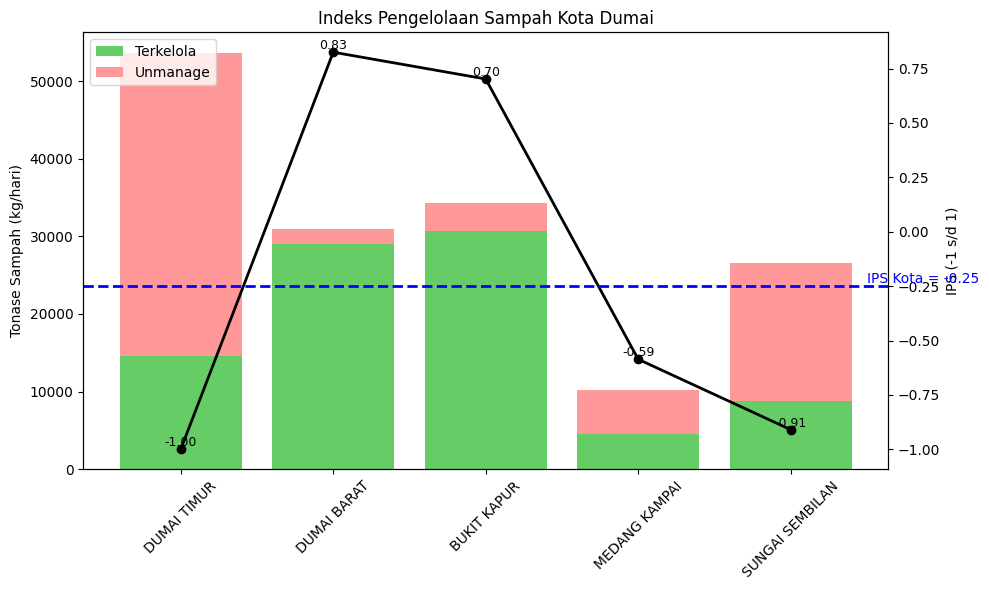

In [7]:
# ========================================================================
# Diagram batang IPS Kota Dumai
# ========================================================================

import matplotlib.pyplot as plt
import numpy as np

# 1. PASTIKAN DATA
# =========================
df = df.fillna(0)

df['Terkelola'] = df['TPA SL'] + df['Sarpras PS'] + df['RT'] + df['Reduksi']
df['Unmanage']  = df['TPA OD'] + df['Leaked'] + df['Hidden']
df['S'] = df['Terkelola'] + df['Unmanage']

# 2. IPS KECAMATAN
# =========================
df['IPS'] = ((df['Terkelola'] / df['S']) - 0.65) / 0.35
df.loc[df['S'] == 0, 'IPS'] = None
df['IPS'] = df['IPS'].clip(-1, 1)

# 3. IPS KOTA
# =========================
K_kota = df['Terkelola'].sum()
S_kota = df['S'].sum()

if S_kota == 0:
    IPS_kota = None
else:
    IPS_kota = ((K_kota / S_kota) - 0.65) / 0.35
    IPS_kota = max(-1, min(1, IPS_kota))

print("IPS Kota:", IPS_kota)

# 4. POSISI X
# =========================
x = np.arange(len(df))
labels = df['Kecamatan']

# 5. PLOT BAR (STACKED)
# =========================
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.bar(x, df['Terkelola'], color='#66CC66', label='Terkelola')
ax1.bar(x, df['Unmanage'], bottom=df['Terkelola'], color='#FF9999', label='Unmanage')

ax1.set_ylabel("Tonase Sampah (kg/hari)")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45)
ax1.set_title("Indeks Pengelolaan Sampah Kota Dumai")

# 6. AXIS IPS
# =========================
ax2 = ax1.twinx()

# garis IPS kecamatan
ax2.plot(x, df['IPS'], color='black', marker='o', linewidth=2)

# label angka IPS per titik
for i, v in enumerate(df['IPS']):
    if pd.notna(v):
        ax2.text(i, v, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

# garis IPS kota
if IPS_kota is not None:
    ax2.axhline(y=IPS_kota, color='blue', linestyle='--', linewidth=2)

    # label garis IPS kota
    ax2.text(len(df)-0.5, IPS_kota, f"IPS Kota = {IPS_kota:.2f}",
             color='blue', va='bottom')

ax2.set_ylabel("IPS (-1 s/d 1)")

# 7. LEGEND
# =========================
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='upper left')

# 8. FINAL
# =========================
plt.tight_layout()
plt.show()

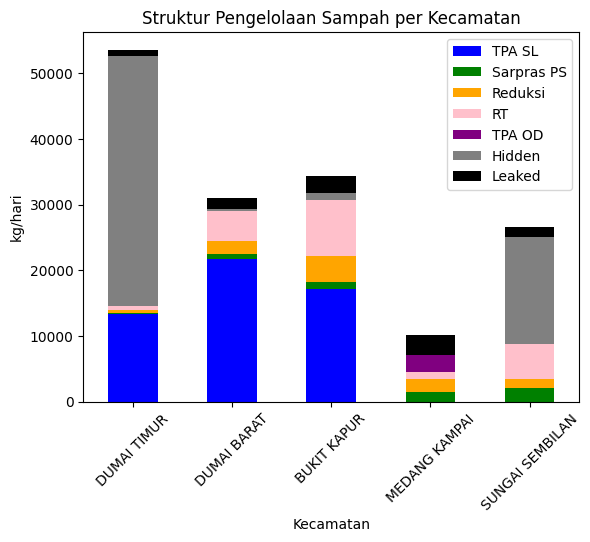

In [8]:
# =======================================================================
# Diagram Pengelolaan Sampah per kecamatan
# ========================================================================

df_plot = df.set_index("Kecamatan")[["TPA SL","Sarpras PS","Reduksi","RT","TPA OD","Hidden","Leaked"]]
#CATATAN :
#   TPA SL = pelayanan armada pemkot ke TPA Sanitary Landfill
#   BS = Bank Sampah, TPST, TPS3R
#   RT = pengurangan sampah di RT (asumsi)
#   Reduksi = Lapak, Kawasan dll
#   TPA OD = pelayanan armada pemkot ke TPA Open Dumping
#   Leaked = TPS Liar, sampah menumpuk tanpa izin (bisa difoto)
#   Hidden = neraca massa sampah BALANCE

df_plot.plot(kind="bar", stacked=True,
             color={"TPA SL":"blue",
             "Sarpras PS":"green",
             "Reduksi":"orange",
             "RT":"pink",
             "TPA OD":"purple",
             "Hidden":"grey",
             "Leaked":"black"})
plt.title("Struktur Pengelolaan Sampah per Kecamatan")
plt.ylabel("kg/hari")
plt.xticks(rotation=45)

plt.show()

In [11]:
# Bersihkan nama kolom

df.columns = df.columns.str.strip()

In [12]:
# Setting tidak ada NaN

df = df.fillna(0)

In [13]:
df['K'] = df['TPA SL'] + df['Sarpras PS'] + df['RT'] + df['Reduksi']
df['S'] = df['K'] + df['TPA OD'] + df['Leaked'] + df['Hidden']

df['IPS'] = ((df['K'] / df['S']) - 0.65) / 0.35

# handle pembagian nol
df.loc[df['S'] == 0, 'IPS'] = None

# clipping
df['IPS'] = df['IPS'].clip(-1, 1)

In [14]:
# Hitung Index Pengelolaan Sampah Kecamatan

def hitung_IPS(TPA_SL, Sarpras_PS, RT, Reduksi, TPA_OD, Leaked, Hidden):
    S = TPA_SL + Sarpras_PS + RT + Reduksi + TPA_OD + Leaked + Hidden
    K = TPA_SL + Sarpras_PS + RT + Reduksi

    if S == 0:
        return None  # setara "" di Excel

    IPS = ((K / S) - 0.65) / 0.35

    # pembatas -1 s/d 1
    IPS = max(-1, min(1, IPS))

    return IPS

In [15]:
print(df[['K','S']])

         K        S
0  14536.0  53600.0
1  29049.0  30940.0
2  30725.0  34300.0
3   4515.0  10150.0
4   8820.0  26600.0


In [16]:
# Klasifikasi IPS

def klasifikasi(x):
    if pd.isna(x):
        return "DATA KOSONG"
    elif -1 <= x <= -0.5:
        return "BURUK"
    elif -0.5 < x < -1e-6:
        return "KURANG"
    elif abs(x) <= 1e-6:
        return "CUKUP"
    elif 1e-6 < x <= 0.75:
        return "BAIK"
    elif 0.75 < x <= 1:
        return "SANGAT BAIK"
    else:
        return "DI LUAR RANGE"

In [17]:
df['kategori_IPS'] = df['IPS'].apply(klasifikasi)

In [18]:
# Tabel IPS

print(df[["Kecamatan","IPS","kategori_IPS"]])

         Kecamatan       IPS kategori_IPS
0      DUMAI TIMUR -1.000000        BURUK
1      DUMAI BARAT  0.825376  SANGAT BAIK
2      BUKIT KAPUR  0.702207         BAIK
3    MEDANG KAMPAI -0.586207        BURUK
4  SUNGAI SEMBILAN -0.909774        BURUK


In [19]:
# =========================
# HITUNG IPS KOTA (AGREGAT)
# =========================

K_kota = df['K'].sum()
S_kota = df['S'].sum()

IPS_kota = ((K_kota / S_kota) - 0.65) / 0.35

# pembatas
IPS_kota = max(-1, min(1, IPS_kota))

print("IPS Kota Dumai:", round(IPS_kota, 3))

IPS Kota Dumai: -0.248


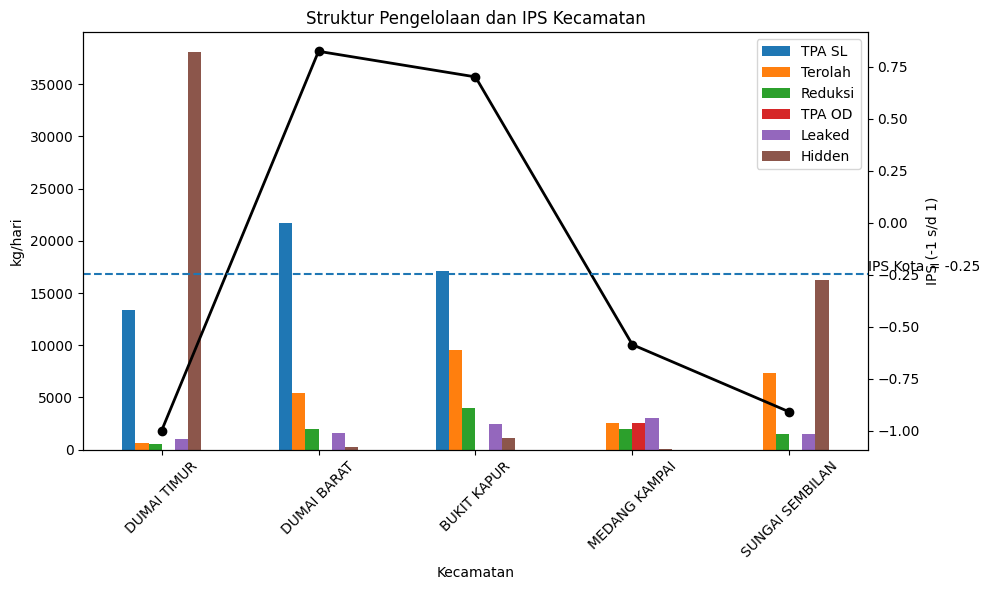

In [20]:
# Diagram Struktur Pengelolaan dan IPS

import matplotlib.pyplot as plt

df_compare = df.set_index("Kecamatan")[[
    "TPA SL", "Terolah", "Reduksi", "TPA OD", "Leaked", "Hidden"
]]

# buat figure
fig, ax1 = plt.subplots(figsize=(10,6))

# bar chart (kg/hari)
df_compare.plot(kind="bar", ax=ax1)

ax1.set_ylabel("kg/hari")
ax1.set_title("Struktur Pengelolaan dan IPS Kecamatan")
ax1.tick_params(axis='x', rotation=45)

# sumbu kedua untuk IPS
ax2 = ax1.twinx()

ax2.plot(df["Kecamatan"], df["IPS"], color='black', marker='o', linewidth=2)
ax2.set_ylabel("IPS (-1 s/d 1)")

# garis horizontal IPS kota
ax2.axhline(y=IPS_kota, linestyle='--')

# label garis
ax2.text(
    x=len(df)-0.5,
    y=IPS_kota,
    s=f'IPS Kota = {IPS_kota:.2f}',
    verticalalignment='bottom'
)

plt.tight_layout()
plt.show()

In [29]:
# Hitung WLSRI

df["SPI"] = df["TPA SL"] / df["Timbulan"]
df["Reduksi_Ratio"] = df["Reduksi"] / df["Timbulan"]
df["Terolah_Ratio"] = df["Terolah"] / df["Timbulan"]
df["Leakage_Index"] = df["%Kebocoran"] / 100

df["WLSRI"] = (
    0.3 * df["SPI"] +
    0.3 * df["Reduksi_Ratio"] +
    0.15 * df["Terolah_Ratio"] -
    0.25 * df["Leakage_Index"]
)

In [30]:
# Klasifikasi WLSRI

def klasifikasi(x):
    if x < 0:
        return "KRISIS"
    elif x < 0.2:
        return "BURUK"
    elif x < 0.4:
        return "SEDANG"
    else:
        return "BAIK"

df["kategori_wlsri"] = df["WLSRI"].apply(klasifikasi)

In [31]:
# Tabel WLSRI

print(df[["Kecamatan","IPS","WLSRI","kategori_wlsri"]])

         Kecamatan       IPS     WLSRI kategori_wlsri
0      DUMAI TIMUR -1.000000 -0.102622         KRISIS
1      DUMAI BARAT  0.825376  0.240253         SEDANG
2      BUKIT KAPUR  0.702207  0.200809         SEDANG
3    MEDANG KAMPAI -0.586207 -0.042519         KRISIS
4  SUNGAI SEMBILAN -0.909774 -0.108905         KRISIS


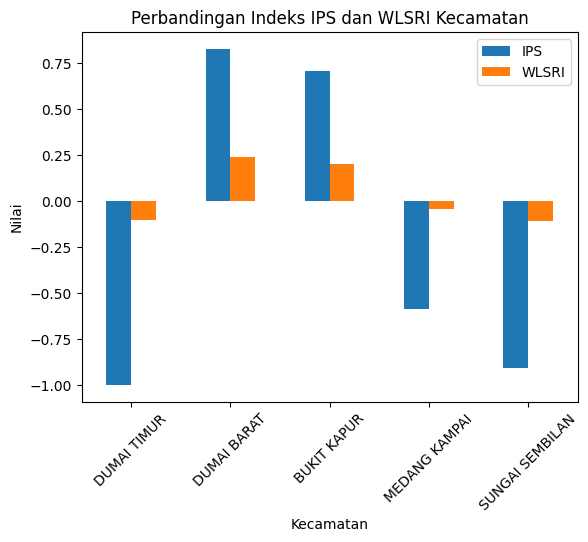

In [32]:
# Diagram Perbandingan Index_Pengurangan dan WLSRI

df_compare = df.set_index("Kecamatan")[["IPS","WLSRI"]]

df_compare.plot(kind="bar")
plt.title("Perbandingan Indeks IPS dan WLSRI Kecamatan")
plt.ylabel("Nilai")
plt.xticks(rotation=45)
plt.show()

# 📊 WLSRI (Waste Local Service Resilience Index) ~ "Angka Pengelolaan"

## 1. Definisi

**WLSRI (Waste Local Service Resilience Index)** adalah indeks komposit yang digunakan untuk menilai tingkat **kemandirian dan ketahanan sistem pengelolaan sampah** di suatu wilayah (misalnya kecamatan).

Indeks ini menggambarkan kemampuan wilayah dalam:

* menangani sampah yang dihasilkan,
* mengurangi ketergantungan pada sistem eksternal,
* meminimalkan kebocoran sampah ke lingkungan.

---

## 2. Komponen Penyusun

WLSRI disusun dari 4 komponen utama:

### 1. SPI (Service Performance Index)

Menggambarkan tingkat pelayanan pengangkutan sampah.

[
SPI = {Terangkut} / {Timbulan}
]

---

### 2. Reduksi Ratio

Menggambarkan kemampuan pengurangan sampah dari sumber (misalnya bank sampah, komposting).

[
Reduksi Ratio = {Reduksi} / {Timbulan}
]

---

### 3. Terolah Ratio

Menggambarkan kemampuan pengolahan sampah di dalam sistem.

[
Terolah Ratio = {Terolah} / {Timbulan}
]

---

### 4. Leakage Index

Menggambarkan tingkat kebocoran sampah ke lingkungan.

[
Leaked Index = {un-Manage} / {Timbulan}
]

dimana:
[
un-Manage = Leaked + Hidden
]

---

## 3. Rumus WLSRI

[
WLSRI = (0.4 * SPI) + (0.2 * Reduksi Ratio) + (0.2 * Terolah Ratio) - (0.2 * Leakage Index)
]

---

## 4. Interpretasi Nilai

| Nilai WLSRI | Interpretasi                       |
| ----------- | ---------------------------------- |
| > 0.70      | Sistem sangat mandiri dan efektif  |
| 0.50 – 0.70 | Sistem cukup baik                  |
| 0.30 – 0.50 | Sistem sedang, perlu intervensi    |
| < 0.30      | Sistem lemah, prioritas penanganan |

---

## 5. Makna Analitis

WLSRI memberikan gambaran keseimbangan antara:

✔ **Kinerja pelayanan (SPI)**
✔ **Upaya pengurangan (Reduksi)**
✔ **Kapasitas pengolahan (Terolah)**
❌ **Kebocoran sistem (Leakage)**

Sehingga indeks ini dapat digunakan untuk:

* menentukan prioritas intervensi kebijakan,
* membandingkan kinerja antar kecamatan,
* mengidentifikasi titik lemah sistem pengelolaan sampah.

---

## 6. Catatan Penting

* Bobot 'Kepedulian' (0.4, 0.2, 0.2, 0.2) dapat disesuaikan dengan kebijakan daerah.
* WLSRI bersifat **komparatif**, sehingga lebih kuat digunakan untuk perbandingan antar wilayah.
* Akurasi indeks sangat bergantung pada kualitas data timbulan dan pengelolaan.

---
